<a href="https://colab.research.google.com/github/basantes2023/MineriaDatos7to./blob/main/telco_churn_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minería de Datos – Predicción de Churn (CNT EP)

Notebook para análisis del **Telco Customer Churn Dataset** usando Python en Google Colab.

Incluye:
- Exploración de datos
- Limpieza
- Preprocesamiento
- Modelos de Machine Learning
- Evaluación y visualización


In [17]:
# =========================================
# IMPORTAR LIBRERÍAS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set(style='whitegrid')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## Subir Dataset

In [18]:
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [19]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploración inicial

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Visualización de Churn

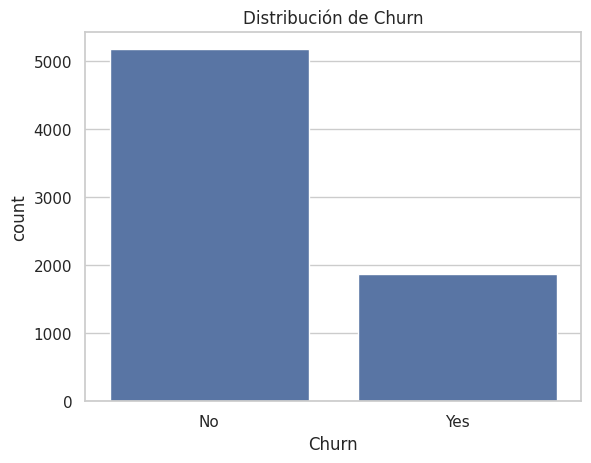

In [22]:
plt.figure()
sns.countplot(x='Churn', data=df)
plt.title('Distribución de Churn')
plt.show()

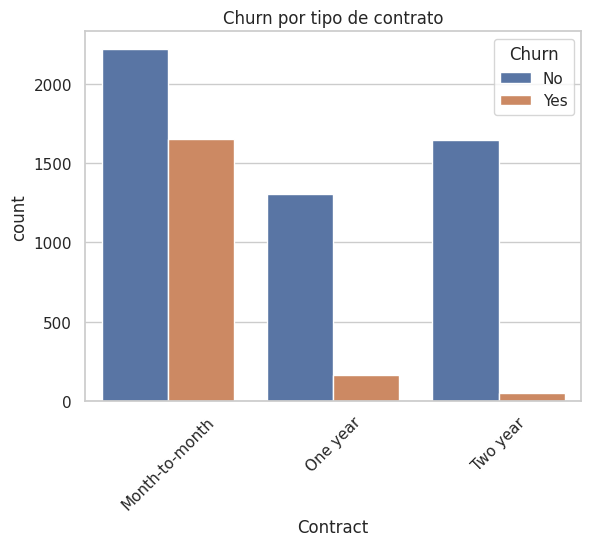

In [23]:
plt.figure()
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn por tipo de contrato')
plt.xticks(rotation=45)
plt.show()

Mapa de Correlación de Variables

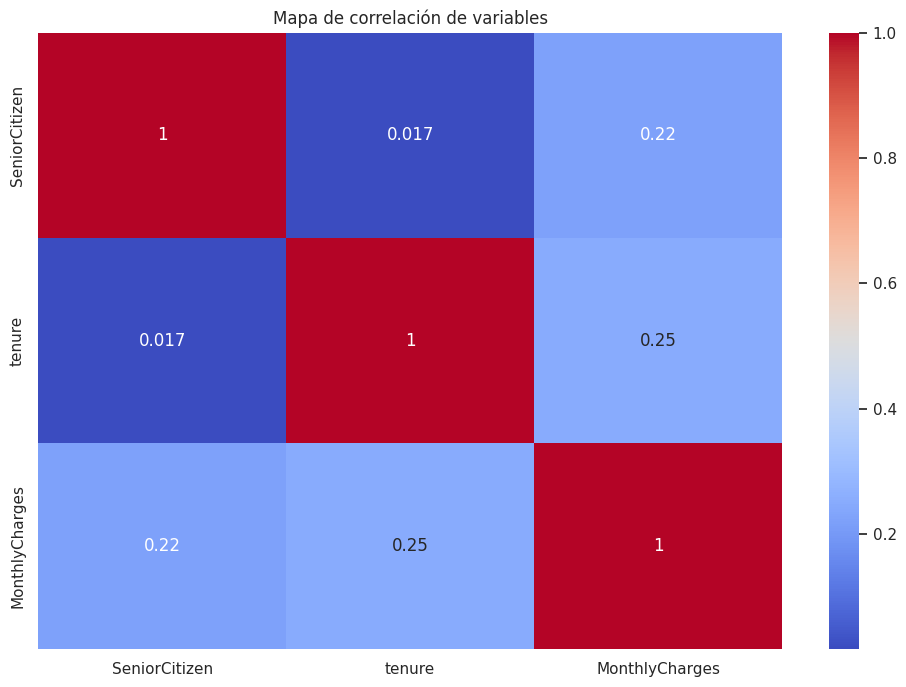

In [24]:

# Seleccionar solo variables numéricas
df_numeric = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")

plt.title("Mapa de correlación de variables")
plt.show()

## Preprocesamiento de datos

In [25]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df.drop('customerID', axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Codificación de variables categóricas

In [26]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
       df.loc[:, col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [27]:
# Convertir Churn a números

df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})
df['Churn'] = df['Churn'].astype(int)

/tmp/ipykernel_12791/3143505730.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})


## División del dataset

In [28]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(5625, 19) (1407, 19)


## Modelo 1 – Regresión Logística

In [29]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(max_iter=5000)

model_log.fit(X_train, y_train)

pred_log = model_log.predict(X_test)

acc_log = accuracy_score(y_test, pred_log)

print("Accuracy Logistic Regression:", acc_log)

Accuracy Logistic Regression: 0.7853589196872779


## Modelo 2 – Árbol de Decisión

In [30]:
model_tree = DecisionTreeClassifier()
model_tree.fit(X_train, y_train)

pred_tree = model_tree.predict(X_test)

acc_tree = accuracy_score(y_test, pred_tree)
print('Accuracy Decision Tree:', acc_tree)

Accuracy Decision Tree: 0.7221037668798863


## Modelo 3 – Random Forest

In [31]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
print('Accuracy Random Forest:', acc_rf)

Accuracy Random Forest: 0.7924662402274343


## Comparación de modelos

In [32]:
resultados = pd.DataFrame({
    'Modelo': ['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy': [acc_log, acc_tree, acc_rf]
})

resultados

,Modelo,Accuracy
0,Logistic Regression,0.785359
1,Decision Tree,0.722104
2,Random Forest,0.792466


## Matriz de Confusión

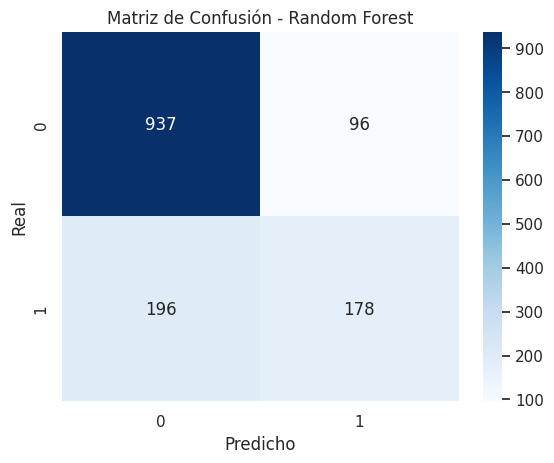

In [33]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

## Reporte de Clasificación

In [34]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Importancia de variables en Random Forest

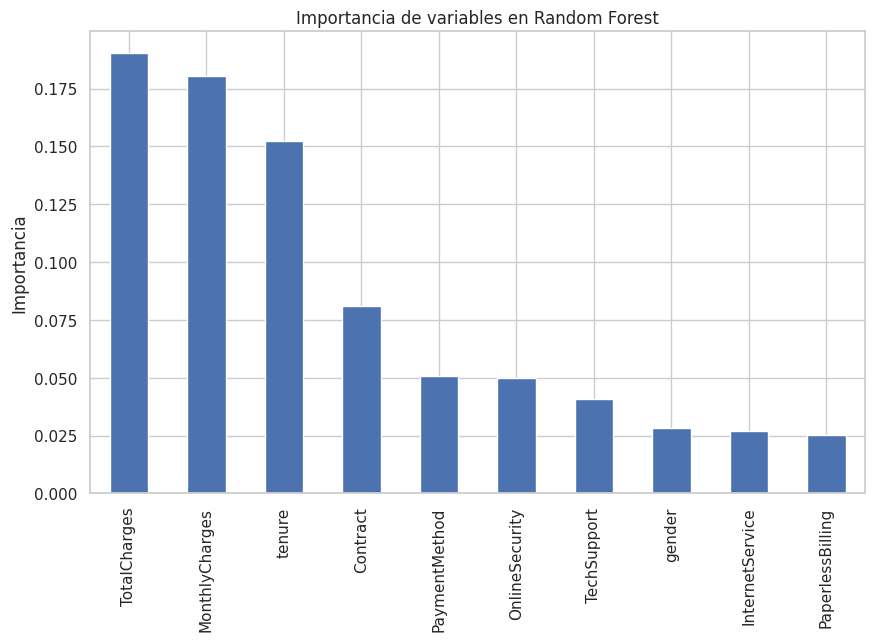

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model_rf.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')

plt.title("Importancia de variables en Random Forest")
plt.ylabel("Importancia")
plt.show()

## Validación Cruzada

In [36]:
scores = cross_val_score(model_rf, X, y, cv=5)

print('Scores:', scores)
print('Promedio:', scores.mean())

Scores: [0.7981521  0.7938877  0.77738265 0.80156472 0.79800853]
Promedio: 0.7937991408533435


**Proceso de exportación y persistencia del modelo**

In [37]:
import joblib

# Guardar modelo entrenado
joblib.dump(model_rf, 'modelo_churn.pkl')

# Guardar columnas del modelo
joblib.dump(X.columns.tolist(), 'columnas.pkl')

print("✅ Modelo y columnas guardados correctamente")

from google.colab import files

files.download('modelo_churn.pkl')
files.download('columnas.pkl')

✅ Modelo y columnas guardados correctamente


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>